# Lab 3: Mine Crafting


As with previous labs, be sure to submit only the `lab3.ipynb` and `lab3.html` version of the lab in your github `Lab3` folder. No more, and no less.

## Introduction

Imagine you are a scientist for a mining company that operates a vertical mine at the Earth's
equator. This is one of the deepest mines on Earth; it's roughly 4 km to the bottom of the shaft.
Your boss proposes to measure the vertical depth of the shaft by dropping a 1 kg test mass and
accurately measuring the time to hit the bottom.

You will be guided in your investigations below and submit your report in the form of this notebook. Be sure to be quantitative in nature, produce highly polished plots, with appropriate titles, units, etc.


A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
|  Gravitational Constant ($G$)        |  $6.6743 \times 10^{-11}$ m$^3$/kg/s$^2$  | 
|  Gravitational Acceleration ($g_o$)  |  9.81 m/s$^2$ (approximate) | 
|  Mass of the Earth ($M_{\oplus}$)    |  $5.972 \times 10^{24}$ kg      | 
|  Mass of the Moon ($M_{m}$)          |  $7.35 \times 10^{22}$ kg     | 
|  Radius of the Earth ($R_{\oplus}$)  |  6378.1 km     | 
|  Radius of the Moon ($R_{m}$)        |   1738.1 km    | 
|  Earth's Rotation Rate at the Equator| $7.272 \times 10^{-5} $ rad/s  | 

In [1]:
G = 6.6743e-11 
g_0 = 9.81 
M_E = 5.972e24 
M_m = 7.35e22 
R_E = 6378.1e3
R_m = 1738.1e3
E_r = 7.272e-5 

import numpy as np 

#important info: QUAD, solve_ivp, and fftr are important. In 1 you are dropping a ball down into the mineshaft 

#in number two you are adding drag, and adding a gravity that depends on the radius g(r).. 

#in number three we take the earth that spins on it's axis, orienting the shaft on the equator, you have
#to add the corealis force to the solve ivp. If you drop it down the shaft will it hit the wall first?

#in number four you take the mineshaft from pole to pole

#in number five take a realistic earth with a core and mantel (different densities) will it drop faster or slower

#in number siz you go to the moon and do the same thing, pole to pole

#in number seven you take that orbit from pole to pole and 3D transform to find the power transfer

## Part 1: The Ideal Case

In this section and the following sections, we calculate the time for the 1 kg test mass to reach the bottom of the mineshaft under a series of increasingly complex assumptions. Remember that a projectile experiencing a constant gravitational force, plus a drag force, obeys the following second
order differential equation:

$$
\frac{d^2y}{dt^2} = -g + \alpha \left| \frac{dy}{dt} \right|^{\gamma}
\tag{1}
$$



where $t$ is time, $y$ is the height, $g$ is the gravitational acceleration,
$\alpha$ is the drag coefficient, and $\gamma$ is the speed dependence
of the drag. For example, for $\gamma=2$, the drag force grows proportionally
to the speed *squared*.  **Hint**: pay particular attention to the sign
conventions in your implementation! The drag, by definition, should *oppose*
the direction of motion.

1. First, make a simple calculation of how long a test mass would 
            take to reach the bottom of the 4km shaft assuming no drag. This is the simple
            free-fall algebraic expression you know from PHYS 171.

2. Next, reduce (1) into a *system* of coupled
            first order differential equations by setting the velocity $v = dy/dt$.

3. Numerically solve (1) using `solve_ivp` assuming $\alpha=0$.
            Plot the position and velocity as a function of time.                              
            Draw a horizontal dashed line at the depth of the bottom of the shaft,
            to make it easy to see.
            Make the plot look nice, including displaying the position on the left axes,
            and plotting the velocity on a second right axis, using matplotlib `twinx`
            capability.        
   In your notebook, label this figure clearly as **Figure 1**.

4. Using the `events` detection capability of `solve_ivp`,
            calculate the time at which the mass hits the bottom of the shaft
            in the case of zero drag ($\alpha=0$). Compare this to your analytic calculation
            and discuss any differences you might see.


In [2]:
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

### 1.1 


In [3]:
# 1.1 Calculation 

# v = v_0 - gt, y = y_0 + v_0t - 1/2gt^2
# -4000 = 0 + 0t - 1/2(9.81)t^2 -> (-4000*2/9.81)^1/2

y_0 = 0 
y = -4000 
v_0 = 0

t_fall = np.sqrt((y*2)/-g_0) #adujst to -g, which is negative (downwards) 
print(t_fall) 

28.55686245854129


The time, t, it takes to reach the bottom of a 4km shaft, assuming no drag, is $ t = 28.6 [s]$

### 1.2 
v = dy/dt so the equation becomes:
$$
\frac{d^2y}{dt^2} = -g + \alpha \left| {v} \right|^{\gamma}
\tag{1b}
$$ \
Which we can call 1b

### 1.3

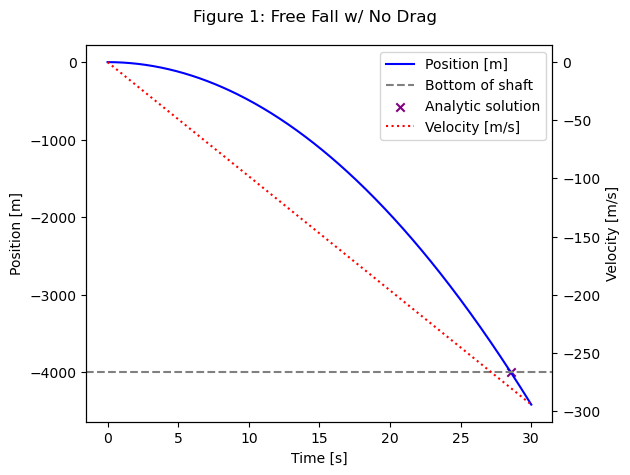

In [4]:
def system (t, z): 
    y, v = z 
    dydt = v
    dvdt = -g_0 #a = 0!
    return [dydt, dvdt]

v0 = 0 
y0 = 0 
z0 = [y0, v0]

t0, t1 = 0, 30 #t = ~ 30, so small buffer to ensure ball drops
t_span = (t0, t1) 
N = 500 #bins
t_eval = np.linspace(*t_span, N) 

sol = solve_ivp(system, t_span, z0, t_eval=t_eval) 

#Figure 1:

#ax1
fig_0, ax1 = plt.subplots() 
ax1.plot(sol.t, sol.y[0], color='blue', label="Position [m]") 
ax1.axhline(-4000, linestyle='--', label="Bottom of shaft", color='gray')
ax1.scatter(t_fall, -4000, color='purple', marker='x', label="Analytic solution") #added out of interest, visualization of time when hit -4000
ax1.set_xlabel("Time [s]") 
ax1.set_ylabel("Position [m]")
# -----
#ax2
ax2 = ax1.twinx()
ax2.plot(sol.t, sol.y[1], linestyle=':', color='red', label="Velocity [m/s]") 
ax2.set_ylabel("Velocity [m/s]") 
# -----
#legends
lines, labels = ax1.get_legend_handles_labels() 
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines + lines2, labels+labels2) 
# -----
plt.suptitle("Figure 1: Free Fall w/ No Drag") #easier than ax1 vs. ax2 title 
plt.tight_layout() 

### 1.4

In [5]:
def ground(t, z): 
    return z[0]+ 4000 

ground.terminal = True
ground.direction = -1 #moving downwards 

sol_event = solve_ivp(system, t_span, z0, events = ground) 

 print("Hit Time:", t_hit) 
print("-"*50) 
print(f"Analytic hit time: {t_fall} vs Numerical hit time: {t_hit}")
print("Analytic and Numeric difference:",t_fall - t_hit)
print("-"*50) 
print(f"There is no noticable difference because solve_ivp has very negligible numerical error and the equation we used with gamma = 0 yields an exact solution, not an approximation.")

Hit Time: 28.556862458541282
--------------------------------------------------
Analytic hit time: 28.55686245854129 vs Numerical hit time: 28.556862458541282
Analytic and Numeric difference: 7.105427357601002e-15
--------------------------------------------------
There is no noticable difference because solve_ivp has very negligible numerical error and the equation we used with gamma = 0 yields an exact solution, not an approximation.


## Part 2: Including Drag and a Variable g

In practice, we cannot ignore drag, and we should also not assume that $g$ is a constant. If you
approximate that the mass of the Earth is distributed homogenously (which it is not!), then the
gravitational constant $g$ will depend on your distance $r$ from the center of the Earth in a simple
linear way:

$$
 g(r) = g_o \left( \frac{r}{R_{\oplus}} \right)
 \tag{2}
$$

where $g_o$ is the gravity at the surface, and $R_{\oplus}$ is the radius of the Earth.

1. Make a new plot that shows the velocity and position as a function of                       
            time assuming $g(y)$. Be careful with coordinate systems!
            The test mass' position should be at the Earth radius at $t=0$, and falling down.
            But for plotting purposes, it will be useful to plot the height
            above the bottom of the shaft.        
            In your notebook, label this figure clearly as **Figure 2**.

2. What effect does incorporating a height-dependent $g$ have on the fall time? Explain.

3. Now, turn on drag, and replot the position and velocity.
            For most things, $\gamma=2$ is a good assumption.
            How can you calibrate the value of $\alpha$? Think about what we did in Lecture 15/16,
            where we assumed a sky-diver's terminal speed was 50 m/s.
            You should assume the same of the test mass.
            What affect does including drag have on the fall time?



### 2.1

Time to reach the bottom: 28.55836042291948


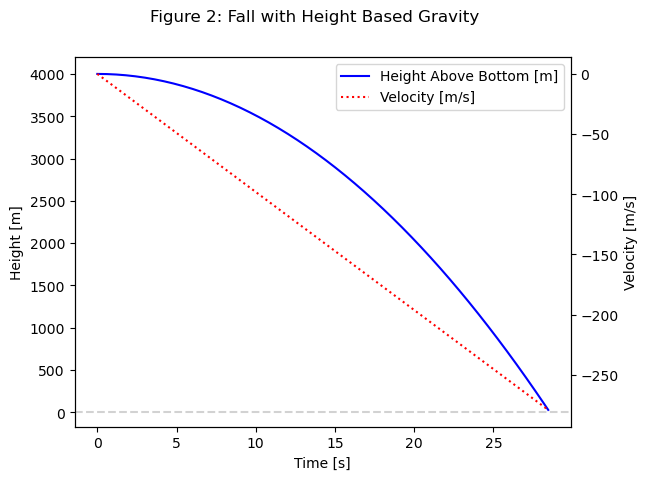

In [6]:
# v = dr/dt, dv/dt = -g_0(r/R_E) 
# r_0 = R_E 
# r = R_E - 4000 
def system_g_var(t, z): 
    r, v = z 
    drdt = v 
    dvdt = -g_0 * (r/R_E)
    return [drdt, dvdt] 

r0 = R_E 
v0 = 0
z0 = [r0, v0] 

r_bottom = R_E - 4000 

def hit_ground_g(t, z): 
    return z[0] - r_bottom 

hit_ground_g.terminal = True 
hit_ground_g.direction = -1 #going down! 

t0b = 0
tb = 100 
t_span = (t0b, tb) 
t_eval = np.linspace(*t_span, 500) 

sol = solve_ivp(system_g_var, t_span, z0, events = hit_ground_g, t_eval=t_eval)
t = sol.t  
r = sol.y[0]
v = sol.y[1] 
h = r - r_bottom


fig, ax1 = plt.subplots() 

ax1.plot(t, h, color='blue', label="Height Above Bottom [m]")
ax1.axhline(0, linestyle='--', color='gray', alpha=0.35) #ground 
ax1.set_xlabel("Time [s]") 
ax1.set_ylabel("Height [m]") 

ax2 = ax1.twinx() 
ax2.plot(t, v, color = 'red', linestyle=":", label="Velocity [m/s]") 
ax2.set_ylabel("Velocity [m/s]") 

fig.suptitle("Figure 2: Fall with Height Based Gravity") 

lines, labels = ax1.get_legend_handles_labels() 
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines + lines2, labels+labels2) 

t_bottom = sol.t_events[0][0] 
print(f"Time to reach the bottom: {t_bottom}") 

### 2.2 
By incorporating a varying g value, the time to reach the bottom of the shaft has increase, and the velocity is no longer constant. We can see that r decreases overtime, so g(r) gets smaller. This causes less acceleration and a slower  build up of velocity.

To see this change, we can look at $\Delta g/ g = 4000/6.37E6 = .06%$ which tells us that it is a miniscule effect, but we can still see the repercusions on the time.

### 2.3

Time to reach the bottom: 83.54308278263785


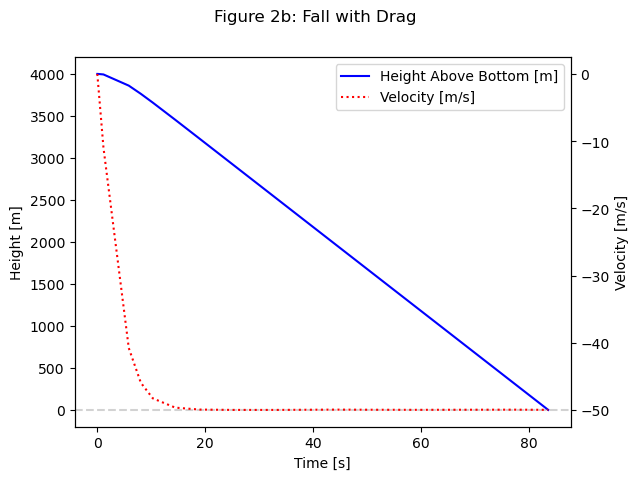

In [7]:
#alpha= g_0/v_t^2
v_t = 50 #from sky-diver problem 
alpha = g_0/(v_t**2)

def system_drag(t, z): 
    r, v = z 
    drdt = v 
    dvdt = -g_0 * (r/R_E) - alpha *abs(v)**2 * np.sign(v) # ensures  v comes out with the correct sign
    return [drdt, dvdt] 
    
t0c, t1c = 0, 200
t_span = (t0c, t1c) 
z0 = [R_E, 0] 

def hit_ground_drag(t, z): 
    return z[0] - r_bottom 

hit_ground_drag.terminal = True 
hit_ground_drag.direction = -1 


sol = solve_ivp(system_drag, t_span, z0, events = hit_ground_drag) 

t = sol.t 
r = sol.y[0] 
v= sol.y[1] 
h = r - r_bottom
fig, ax1 = plt.subplots() 

ax1.plot(t, h, color='blue', label="Height Above Bottom [m]")
ax1.axhline(0, linestyle='--', color='gray', alpha=0.35) #ground 
ax1.set_xlabel("Time [s]") 
ax1.set_ylabel("Height [m]") 

ax2 = ax1.twinx() 
ax2.plot(t, v, color = 'red', linestyle=":", label="Velocity [m/s]") 
ax2.set_ylabel("Velocity [m/s]") 

fig.suptitle("Figure 2b: Fall with Drag") 

lines, labels = ax1.get_legend_handles_labels() 
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines + lines2, labels+labels2) 

t_bottom = sol.t_events[0][0] 
print(f"Time to reach the bottom: {t_bottom}") 

## Part 3: The Coriolis Force

Since the Earth is rotating, there is a Coriolis force on the test mass as it falls.
The force can be quite large.
For example, imagine the mine shaft is on the Earth's equator and pointed towards
the Earth's center.
The equator rotates at about half a kilometer per second.
So once the test mass has fallen for some time, it will bump into the wall,
unless the shaft is very wide.
The Coriolis force $\vec{F_c}$ is:

$$
 \vec{F_c} = -2m \, \left( \vec{\Omega} \times \vec{v} \right)
 \tag{3}
$$

where $\vec{\Omega}$ is the Earth's rotation rate for a vector along $\hat{z}$ and $m$ is the mass of the object (1 kg for the test mass in this case).
For a mine shaft on the equator, we might pick a right-handed coordinate system
with the $\hat{x}$ axis along the East, $\hat{y}$ down into the mine shaft,
and $\hat{z}$ along the North.
This implies the component of the force are:

\begin{equation}
        F_{c_x} = + 2m \, \Omega v_y     \tag{4}
\end{equation}
\begin{equation}
        F_{c_y} = - 2m \, \Omega v_x     \tag{5}
\end{equation}
\begin{equation}
        F_{c_z} = 0     \tag{6}
\end{equation}

1. Extend and update your differential equations of motion 
                to include the Coriolis force. You will need to add a Coriolis
                acceleration term to your equation for the depth coordinate (remember, $F=ma$),
                and additionally, start tracking the velocity and position 
                in the transverse direction (``side-to-side'' in the shaft).

2. Plot the transverse position of the object as a function of depth, initially assuming $\alpha=0$.
                        That is, both axes will have units of distance. 
                Plot ``dots" every few seconds so that you can see
                how the particle moves over time.
                Note that your depth and transverse axes are likely to have very
                different length scales.
                The depth will have a range of 4 km,
   while the transverse direction is about 5m.       
                In your report, this should be **Figure 3**.                

3. If the mine shaft is 5m wide, and you drop the test mass 
                        from the center, does the test mass reach the bottom?
                Or does it bump into the wall first?

4. Now turn drag back on. Does drag make any difference here?




### 3.1 & 3.2
We now know: 

$\frac {dx}{dt} = v_x$ \
$\frac {dy}{dt} = v_y$ \
$\frac {dv_x}{dt} = 2{\Omega}v_y$ \
$\frac {dx}{dt} = -g - 2{\Omega}v_x$ 

Which gives us the extended diff eq

Text(0.5, 1.0, 'Figure 3: Transverse Position vs. Depth')

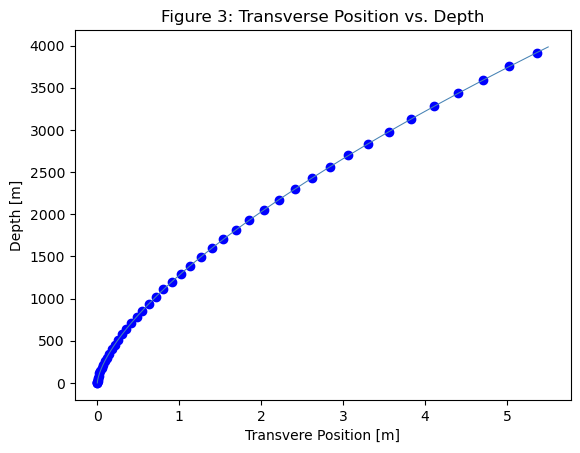

In [8]:
omega = E_r 
r_bottom = R_E - 4000

def system_coriolis(t, z): 
    x, vx, y, vy = z 

    dxdt = vx 
    dvxdt = 2 * omega * vy 

    dydt = vy 
    dvydt = g_0 - (2 * omega * vx) #positive g for depth

    return [dxdt, dvxdt, dydt, dvydt] 

def hit_bottom(t, z): 
    return z[2] - 4000 
hit_bottom.terminal = True
hit_bottom.direction = 1 

x0 = 0 
vx0 = 0
y0 = 0
vy0 = 0 
z0 = [x0, vx0, y0, vy0] 

t_span = (0, 30) 
t_eval = np.linspace(*t_span, 500) 

sol = solve_ivp(system_coriolis, t_span, z0, events=hit_bottom, t_eval=t_eval) 

t = sol.t
x = sol.y[0] 
y = sol.y[2] 

fig, ax1 = plt.subplots() 
ax1.plot(x, y, color="steelblue", lw=.75) 
ax1.scatter(x[::10], y[::10], color="blue") #random dots 
ax1.set_xlabel("Transvere Position [m]") 
ax1.set_ylabel("Depth [m]") 
ax1.set_title("Figure 3: Transverse Position vs. Depth") 


### 3.3

In [9]:
#shaft half-width = 2.5m 
x_max = np.max(np.abs(x)) 
print(f"With a value of |x_max| = {x_max}, it hits the wall before the bottom")

With a value of |x_max| = 5.502985926613618, it hits the wall before the bottom


### 3.4

With drag turned on, the traverse motion is reduced slightly, but the coriolis still causes sideways deflection and drag does not prevent wall contact. The mass stops accelerating at a certain point, but the coriolis force reaches a constant max. The drag DOES act to stop the horizontal motion and dampen the deflection (this system just has too substantial of a deflection).

## Part 4: An infinitely deep mine


Now, let us consider the theoretical case of an infinitely deep mine -- that is,
a tunnel which traverses the full diameter of the Earth.
For convenience, imagine the tunnel goes from pole-to-pole,
such that $\vec{\Omega} \times \vec{v} = 0$, and the Coriolis force
can be neglected, as well as the drag force.

Additionally, continue assuming a constant density Earth.

1. Again, plot the depth and velocity as a function of time.
               (Be careful with the meaning of $y$, as the particle can theoretically
                traverse fully through to the other side of the Earth.)
                Comment on what you see in the graph.       
                In your notebook, label this figure clearly as **Figure 4**.                

2. How long will it take for the object to reach the other side? 
                At what time does the object reach the center of the Earth,
                and at what speed?

3. How does this ``crossing-time" compare to the orbital period, where you assume
                the object is on a circular orbit, in centripetal balance
                with the attractive force of the gravity.
                \begin{equation}
                        \frac{v^2}{R} = \frac{GM}{R^2}   \tag{7}
                \end{equation}
                gives the orbital speed $v$ for a given Earth radius $R$ and 
                Earth mass $M$.





### 4.1 

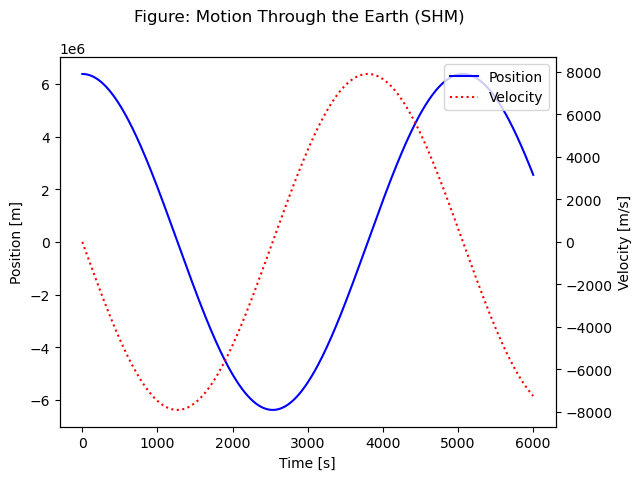

In [10]:
def system_shm(t, z): 
    r, v = z 
    drdt = v 
    dvdt = -(g_0/R_E) * r
    return [drdt, dvdt] 

r0 = R_E 
v0 = 0 
z0 = [r0, v0] 

t_span = (0, 6000) 
t_eval = np.linspace(*t_span, 1000) 

sol = solve_ivp(system_shm, t_span, z0, t_eval=t_eval) 

t = sol.t 
r = sol.y[0] 
v = sol.y[1] 

fig, ax1 = plt.subplots() 

ax1.plot(t, r, color="blue", label="Position") 
ax1.set_xlabel("Time [s]") 
ax1.set_ylabel("Position [m]") 

ax2 = ax1.twinx() 
ax2.plot(t, v, color="red", linestyle=":", label="Velocity") 
ax2.set_ylabel("Velocity [m/s]") 

fig.suptitle("Figure: Motion Through the Earth (SHM)") 

lines, labels = ax1.get_legend_handles_labels() 
lines2, labels2 = ax2.get_legend_handles_labels()

plt.legend(lines + lines2, labels+labels2) 

The motion is sinusoidal, charactersitic of SHM. The object accelerates toward the center, reaches maximum speed at the center of the Earth, and the decelerates as it movse to the opposite side. This motion repeats periodically

### 4.2 & 4.3 

In [11]:
#Calculations
w = np.sqrt(g_0/R_E) 

T = 2 * np.pi * np.sqrt(R_E/g_0) #SHM of earth

t_half = T/2 
t_center = T/4

v_max = w*R_E 

T_orbit = 2*np.pi*np.sqrt(R_E/g_0)  #using g_0 = GM/R_E^2

print(w) 
print(T, t_half, t_center) 
print(v_max) 
print(T_orbit) 

0.001240191760354882
5066.301444690817 2533.1507223454087 1266.5753611727043
7910.067066719473
5066.301444690817


Time to center: $t = 21.1  [mins] $  
Time to other side: $t = 42 [mins]$ \
Maximum speed at center: $v = 7900 [m/s]$ 

The crossing time is equal to the orbital period for a circular orbit at Earth's surface. This is because both depend on the ratio R_E/g_0 

## Part 5: A non-uniform Earth

Finally, let us consider the case of a non-uniform Earth, and continue assuming we have no drag. We know from geology
that the density increases towards the center.
It rises from about 2-3 g/cm$^3$ near the surface, to more like 13 near the center.
A simple model for the density $\rho$ as a function of distance from the center of the Earth $r$ is:

$$
\rho(r) = \rho_n \left( 1 - \frac{r^2}{R_{\oplus}^2} \right)^n   \tag{8}
$$

where $n$ is some exponent, and $\rho_n$ is a normalizing constant.
The case of $n=0$ is the constant density Earth, while $n=2$ is closer to the real value.
Note that the total mass of the Earth, $M$, must be conserved.
Since the mass is the volume integral over the density:

\begin{equation}
        M = \int_V \rho(r) dV = \int_0^{2\pi} \int_0^{\pi} \int_0^{R_{\oplus}} \rho(r) r^2 \sin \phi \, dr \, d\phi \,d\theta = 4 \pi \int_0^{R_{\oplus}} \rho(r) r^2 \, dr
        \tag{9}
\end{equation}

you will need to recompute the density constant $\rho_n$ for each case of $n>0$,
You can use the `quad` integrator for this.
Note that the analytic solution is straightforward to do by hand for $n=0$,
and still manageable for $n=1,2$.
You might consider doing that integral to make sure your method is right, 
and then you can be confident for $n>0$.

1.  Plot the normalized density profile (that is, set $\rho_n=1$) as a function of radius for $n=0, 1, 2, 9$.            
              Put them all on the same plot, with a clear legend.       
              In your notebook, label this figure clearly as **Figure 5**.

2. Now, plot the force profile as a function of radius for $n=0, 1, 2, 9$.         
                This step will show you if your normalization factor $\rho_n$
                is correct, because the surface force must be the same for all $n$.       
              In your notebook, label this figure clearly as **Figure 6**.                

3. Then, plot the position and velocity as a function of time for $n=0, 1, 2, 9$
              as you did in Figure 1/2.         
              In your notebook, label this figure clearly as **Figure 7**.              

4. For $n=0, 1, 2, 9$, compute the time to reach the center, 
                and the speed achieved there.





### 5.1 (Density)

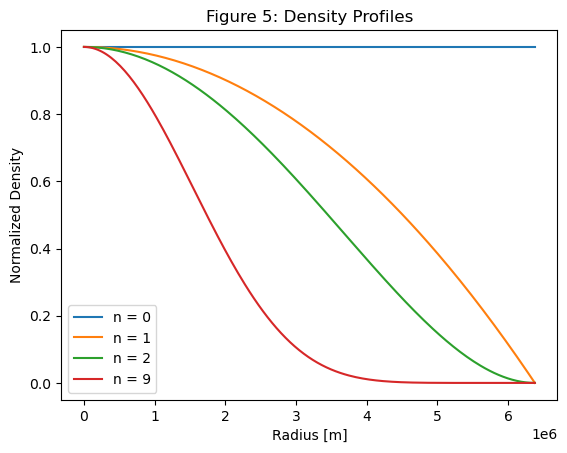

In [81]:
from scipy.integrate import quad, solve_ivp 

r_vals = np.linspace(0, R_E, 200) 

fig, ax = plt.subplots() 

for n in [0, 1, 2, 9]: 
    rho = (1 - (r_vals**2 / R_E**2))**n
    ax.plot(r_vals, rho, label=f"n = {n}") 

ax.set_xlabel("Radius [m]") 
ax.set_ylabel("Normalized Density") 
ax.set_title("Figure 5: Density Profiles") 
ax.legend() 

### 5.2 (Forces)

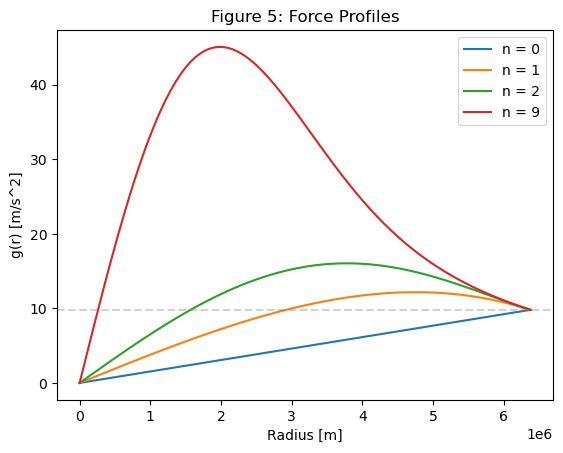

In [80]:
def rho_norm(n):  
    integrand = lambda r: (1 - (r**2/R_E**2))**n * r**2 
    integral, _ = quad(integrand, 0, R_E)
    return M_E / (4 * np.pi * integral) 

def M_enclosed(r, n, rho_n): 
    integrand = lambda rp: rho_n * (1 - (rp**2/R_E**2))**n * rp**2
    val, _ = quad(integrand, 0, r) 
    return 4 * np.pi * val 

def g_r(r, n, rho_n): 
    if r == 0:
        return 0 
    return G * M_enclosed(r, n, rho_n) / r**2
    
fig, ax = plt.subplots() 
r_vals = np.linspace(0, R_E, 200) 

for n in [0, 1, 2, 9]: 
    rho_n = rho_norm(n) 
    
    g_vals = [] 
    for r in r_vals: 
        g_vals.append(g_r(r, n, rho_n)) 

    ax.plot(r_vals, g_vals, label=f"n = {n}") 

ax.axhline(g_0, linestyle='--', color='gray', alpha=0.35) #gravity 
ax.set_xlabel("Radius [m]") 
ax.set_ylabel("g(r) [m/s^2]") 
ax.set_title("Figure 5: Force Profiles") 
ax.legend() 

### 5.3 (Equations of Motion)

Text(0.5, 0.98, 'Figure 7: Position vs. Velocity of [0, 1, 2, 9]')

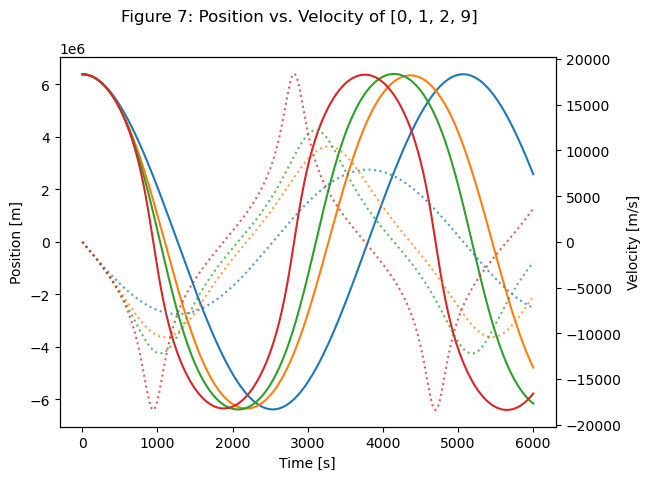

In [111]:
fig, ax1 = plt.subplots() 
ax2 = ax1.twinx() 

t_span = (0, 6000)
t_eval = np.linspace(*t_span, 500) 
z0 = (R_E, 0) 

for n in [0, 1, 2, 9]: 
    rho_n = rho_norm(n) 

    def system(t, z): 
        r, v = z 
        drdt = v 
        dvdt = -g_r(r, n, rho_n) 
        return [drdt, dvdt]
    
    sol = solve_ivp(system, t_span, z0, t_eval=t_eval) 
    
    t = sol.t  
    r = sol.y[0]
    v = sol.y[1] 

    ax1.plot(t, r, linestyle= '-', label=f"r(t), n = {n}") 
    ax2.plot(t, v, linestyle=':', alpha = 0.75, label=f"v(t), n = {n}") 


#misc plot labels and designs 
ax1.set_ylabel("Position [m]") 
ax1.set_xlabel("Time [s]") 
ax2.set_ylabel("Velocity [m/s]") 

plt.suptitle("Figure 7: Position vs. Velocity of [0, 1, 2, 9]")

### 5.4 

In [113]:
r0 = R_E 
v0 = 0

def hit_center(t, z): 
    r, v = z 
    return r

hit_center.terminal = True
hit_center.direction = -1 

for n in [0, 1, 2, 9]: 
    rho_n = rho_norm(n) 

    def system(t, z): 
        r, v = z 
        drdt = v 
        dvdt = -g_r(r, n, rho_n) 
        return [drdt, dvdt]
    
    sol = solve_ivp(system, t_span, (r0, v0), events = hit_center)

t_center = sol_event.t_events[0][0] 
v_center = sol_event.y_events[0][0][1]

print(f"Time to center = {t_center} [mins] ") 
print(f"Velocity at Center = {v_center} [m/min]") 

Time to center = 28.556862458541282 [mins] 
Velocity at Center = -280.1428207182902 [m/min]


## Part 6: A Lunar Mine Shaft


Finally, with all of the framework in place, consider the case where the
the mine shaft is instead dug on the moon.

1. Compute the travel time to the center of the moon
                in case we dig a pole-to-pole mine shaft,
                so that we can again avoid the Coriolis force, though
                on the moon this force is very small. No drag force either,
   which is actually realistic for the moon!
3. What is the density (if you asssume a constant density) 
                of the moon compared to that of earth? 
4. How does the fall/orbit time depend on density? See if you can discover a 
        relationship between the density and the fall time. You should think beyond strictly linear 
        relationships.



This problem can actually be
done on paper, and then you can compare the answer with that for the homogenous earth
you did in Part 4.


## Part 7: Fourier Transforming Orbits

Take the solutions for n=0 and n=9 of the orbits in Part 5 (the inhomogeneous earth) and Fourier Transform them, to see what frequencies (*1/periods*) are dominant in the power spectra. Comment on what you see.

**Hint:** you could take the orbit from the previous integration in Part 5c, but it is useful to increase the integration time and sampling to get more meaningful smooth enough curves. We discussed this in class.

For an example of a spectral analysis of galactic orbits see https://articles.adsabs.harvard.edu/pdf/1982ApJ...252..308B

Describe what we see here: